<a href="https://colab.research.google.com/github/kainatata123-dot/Data-Science-Portfolio/blob/main/Financial_Fraud_Detection_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Financial Fraud Detection
### Data Analyst Portfolio Project — Targeting ING Bank Turkey & DenizBank

---

## What is this project about?

Every bank and fintech in Turkey needs to detect fraudulent transactions. ING Bank Turkey, DenizBank, Akbank, and Garanti BBVA all have data analyst roles that specifically mention fraud detection.

Fraud detection has one big challenge that makes it different from most data science problems: **class imbalance**. Out of every 1,000 bank transactions, maybe 2 are fraudulent. If your model predicts "not fraud" for every single transaction, it achieves 99.8% accuracy — but catches zero fraud. Accuracy is the wrong metric here.

This notebook shows you:
1. Why accuracy fails for imbalanced data
2. The right metrics: precision, recall, F1, and ROC-AUC
3. How to handle class imbalance (SMOTE, class weights)
4. How to build and compare models
5. How to set the decision threshold based on business cost
6. How to explain the model to a non-technical risk officer

## The business problem

We are analysts at a Turkish bank. The risk team wants a model that flags suspicious transactions for manual review. There are two types of mistakes:

- **False negative (missed fraud):** We approve a fraudulent transaction. The bank loses money — typically 50–500 TRY per transaction.
- **False positive (false alarm):** We flag a legitimate transaction. The customer is annoyed and may churn — cost roughly 20 TRY per case (customer service + goodwill).

Since missing fraud costs more than a false alarm, we tune our model to have **high recall** (catch most fraud) even at the cost of some precision (more false alarms).

---
**Dataset:** IEEE-CIS Fraud Detection (Kaggle) — simulated here with the same statistical properties

**References:**
- Chawla et al. (2002) *SMOTE: Synthetic Minority Over-sampling Technique*
- Dal Pozzolo et al. (2015) *Calibrating Probability with Undersampling for Unbalanced Classification*

In [1]:
!pip install imbalanced-learn xgboost shap -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, f1_score, precision_score, recall_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#0d1117',
    'axes.edgecolor': '#30363d', 'grid.color': '#21262d',
    'axes.labelcolor': '#c9d1d9', 'xtick.color': '#8b949e',
    'ytick.color': '#8b949e', 'text.color': '#c9d1d9', 'font.size': 11
})

SEED = 42
np.random.seed(SEED)
print('Ready.')

Ready.


## Step 1 — Dataset

We simulate a realistic Turkish bank transaction dataset. Each row is one transaction. Features include:

| Feature | Type | Description |
|---|---|---|
| transaction_amount | Numeric | Amount in TRY |
| hour_of_day | Numeric | 0-23 |
| day_of_week | Numeric | 0=Monday |
| merchant_category | Categorical | e.g. grocery, electronics, fuel |
| card_present | Binary | 1 = physical card used |
| distance_from_home_km | Numeric | How far from home location |
| transactions_last_24h | Numeric | Velocity feature |
| avg_amount_last_30d | Numeric | Behavioural baseline |
| amount_vs_avg | Numeric | Ratio of this transaction to baseline |
| new_merchant | Binary | 1 = first time at this merchant |
| international | Binary | 1 = foreign transaction |

### The key challenge: 0.2% fraud rate

Only 2 in every 1,000 transactions are fraudulent. This is realistic for retail banking. It means:
- The dataset is massively **imbalanced**
- Models that ignore this will learn to just predict "not fraud" always
- We need special techniques to force the model to learn the fraud pattern

In [5]:
np.random.seed(SEED)

N_LEGIT = 98000
N_FRAUD = 2000    # ~2% fraud rate — realistic for Turkish retail banking
N_TOTAL = N_LEGIT + N_FRAUD

MERCHANT_CATS = ['grocery','fuel','restaurant','electronics','clothing','atm','online','pharmacy','travel']

def generate_transactions(n, is_fraud):
    """
    Generate realistic transaction features.

    Fraud transactions have different statistical properties:
    - Higher amounts (fraudsters maximise value)
    - More likely at night or weekend
    - More often at new merchants
    - More often international
    - More often card-not-present (online)
    - Higher velocity (multiple transactions quickly)
    - Amount much higher than customer's baseline
    """
    if is_fraud:
        amount     = np.random.lognormal(6.5, 1.0, n)  # higher amounts: ~700 TRY avg
        hour_probs = np.array([0.08,0.08,0.09,0.09,0.07,0.04,0.02,0.01,0.01,0.01,
                                   0.01,0.01,0.02,0.02,0.03,0.03,0.05,0.06,0.07,0.07,
                                   0.07,0.07,0.07,0.07])
        hour       = np.random.choice(range(24), n, p=hour_probs / hour_probs.sum())
        dow        = np.random.randint(0, 7, n)
        cat        = np.random.choice(MERCHANT_CATS, n,
                        p=[0.05,0.05,0.05,0.25,0.10,0.15,0.25,0.02,0.08])
        card_pres  = np.random.binomial(1, 0.25, n)   # mostly card-not-present
        dist       = np.random.exponential(150, n)     # far from home
        vel_24h    = np.random.poisson(4, n)           # high velocity
        avg_30d    = np.random.lognormal(5.0, 0.6, n)  # normal baseline
        amt_ratio  = amount / (avg_30d + 1)
        new_merch  = np.random.binomial(1, 0.75, n)   # often new merchant
        intl       = np.random.binomial(1, 0.35, n)   # often international
    else:
        amount     = np.random.lognormal(5.5, 0.8, n)  # lower amounts: ~250 TRY avg
        hour_probs = np.array([0.01,0.01,0.01,0.01,0.01,0.02,0.04,0.07,0.08,0.08,
                                   0.07,0.07,0.07,0.07,0.07,0.07,0.07,0.07,0.06,0.05,
                                   0.04,0.03,0.02,0.01])
        hour       = np.random.choice(range(24), n, p=hour_probs / hour_probs.sum())
        dow        = np.random.randint(0, 7, n)
        cat        = np.random.choice(MERCHANT_CATS, n,
                        p=[0.25,0.12,0.15,0.08,0.12,0.08,0.10,0.05,0.05])
        card_pres  = np.random.binomial(1, 0.80, n)   # mostly physical
        dist       = np.random.exponential(8, n)       # close to home
        vel_24h    = np.random.poisson(1.5, n)         # normal velocity
        avg_30d    = np.random.lognormal(5.0, 0.6, n)
        amt_ratio  = amount / (avg_30d + 1)
        new_merch  = np.random.binomial(1, 0.20, n)   # usually known merchants
        intl       = np.random.binomial(1, 0.05, n)   # rarely international

    return pd.DataFrame({
        'transaction_amount':    amount.round(2),
        'hour_of_day':           hour,
        'day_of_week':           dow,
        'merchant_category':     cat,
        'card_present':          card_pres,
        'distance_from_home_km': dist.round(1),
        'transactions_last_24h': vel_24h,
        'avg_amount_last_30d':   avg_30d.round(2),
        'amount_vs_avg_ratio':   amt_ratio.round(3),
        'new_merchant':          new_merch,
        'international':         intl,
        'is_fraud':              int(is_fraud),
    })

df_legit = generate_transactions(N_LEGIT, is_fraud=False)
df_fraud = generate_transactions(N_FRAUD, is_fraud=True)
df = pd.concat([df_legit, df_fraud], ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f'Dataset: {len(df):,} transactions')
print(f'Fraud:   {df.is_fraud.sum():,} ({df.is_fraud.mean():.2%})')
print(f'Legit:   {(df.is_fraud==0).sum():,} ({1-df.is_fraud.mean():.2%})')
print()
print('Key feature differences (fraud vs legit):')
compare = df.groupby('is_fraud')[['transaction_amount','distance_from_home_km',
                                    'transactions_last_24h','amount_vs_avg_ratio',
                                    'international','new_merchant']].mean().round(3)
compare.index = ['Legit','Fraud']
print(compare.to_string())

Dataset: 100,000 transactions
Fraud:   2,000 (2.00%)
Legit:   98,000 (98.00%)

Key feature differences (fraud vs legit):
       transaction_amount  distance_from_home_km  transactions_last_24h  amount_vs_avg_ratio  international  new_merchant
Legit             337.428                  8.018                  1.498                2.686          0.051         0.197
Fraud            1058.808                153.947                  3.992                8.710          0.342         0.749


## Step 2 — Why Accuracy Fails and What to Use Instead

### The accuracy paradox

With 2% fraud rate, a model that always predicts "not fraud" achieves 98% accuracy. That sounds impressive but is completely useless — it catches zero fraud.

### The right metrics for imbalanced problems

**Precision:** Of all transactions we flagged as fraud, what fraction actually were fraud?
$$\text{Precision} = \frac{\text{True Positives}}{\text{True Positives + False Positives}}$$
High precision = few false alarms. The risk team is not overwhelmed with cases.

**Recall (Sensitivity):** Of all actual fraud transactions, what fraction did we catch?
$$\text{Recall} = \frac{\text{True Positives}}{\text{True Positives + False Negatives}}$$
High recall = few missed frauds. The bank loses less money.

**F1 Score:** The harmonic mean of precision and recall. Balances both.
$$\text{F1} = \frac{2 \times \text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

**ROC-AUC:** The area under the ROC curve. Measures the model's ability to rank fraud higher than legitimate transactions, regardless of threshold. 1.0 = perfect, 0.5 = random.

**PR-AUC (Average Precision):** For highly imbalanced data, the PR curve is more informative than the ROC curve because it focuses on the minority class performance.

In [6]:
# Feature engineering and preprocessing
le = LabelEncoder()
df['merchant_cat_enc'] = le.fit_transform(df['merchant_category'])

# Time features: cyclical encoding
df['hour_sin'] = np.sin(2*np.pi*df.hour_of_day/24)
df['hour_cos'] = np.cos(2*np.pi*df.hour_of_day/24)
df['dow_sin']  = np.sin(2*np.pi*df.day_of_week/7)
df['dow_cos']  = np.cos(2*np.pi*df.day_of_week/7)

# Log-transform skewed features
df['log_amount']   = np.log1p(df.transaction_amount)
df['log_distance'] = np.log1p(df.distance_from_home_km)
df['log_avg_30d']  = np.log1p(df.avg_amount_last_30d)

FEATURES = [
    'log_amount', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
    'merchant_cat_enc', 'card_present', 'log_distance',
    'transactions_last_24h', 'log_avg_30d', 'amount_vs_avg_ratio',
    'new_merchant', 'international'
]
TARGET = 'is_fraud'

X = df[FEATURES].values
y = df[TARGET].values

# Stratified split — ensures fraud rate is the same in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)

# Scale features — required for Logistic Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {len(X_train):,} ({y_train.sum()} fraud = {y_train.mean():.2%})')
print(f'Test:  {len(X_test):,}  ({y_test.sum()} fraud = {y_test.mean():.2%})')
print()

# Demonstrate the accuracy paradox
print('THE ACCURACY PARADOX:')
dummy_preds = np.zeros(len(y_test))  # always predict "not fraud"
dummy_acc   = (dummy_preds == y_test).mean()
dummy_recall = 0.0  # catches no fraud
print(f'  Model that always predicts NOT FRAUD:')
print(f'  Accuracy = {dummy_acc:.2%}  ← looks good!')
print(f'  Recall   = {dummy_recall:.2%}  ← catches ZERO fraud!')
print(f'  This is why accuracy is the WRONG metric for fraud detection.')

Train: 75,000 (1500 fraud = 2.00%)
Test:  25,000  (500 fraud = 2.00%)

THE ACCURACY PARADOX:
  Model that always predicts NOT FRAUD:
  Accuracy = 98.00%  ← looks good!
  Recall   = 0.00%  ← catches ZERO fraud!
  This is why accuracy is the WRONG metric for fraud detection.


## Step 3 — Handling Imbalance and Training Models

### Three approaches to class imbalance

**1. Class weights** — tell the model that fraud mistakes are more costly. The model assigns a higher penalty to misclassifying the minority class. Simple and effective — the standard first choice.

**2. SMOTE (Synthetic Minority Over-sampling Technique)** — generate synthetic fraud examples by interpolating between real fraud transactions. For each fraud example, SMOTE finds its k nearest neighbours (also fraud) and creates new examples along the line between them. This gives the model more fraud examples to learn from.

**Why not just duplicate fraud examples?** Pure duplication leads to overfitting — the model memorises those specific examples. SMOTE creates slightly different examples, forcing the model to learn the general pattern.

**3. Threshold tuning** — after training, shift the decision threshold from the default 0.5. Lowering it (e.g. to 0.2) means we flag more transactions as fraud, increasing recall at the cost of precision. We choose the threshold that minimises the total business cost.

### Models we compare
- Logistic Regression (interpretable, fast baseline)
- Random Forest (robust, handles non-linear patterns)
- XGBoost (state of the art for tabular fraud detection)

In [7]:
# Compute scale_pos_weight for XGBoost
fraud_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'Class weight ratio (legit/fraud): {fraud_weight:.0f}x')
print('This tells models: one fraud mistake = {:.0f}x worse than one legit mistake'.format(fraud_weight))
print()

# ── Model 1: Logistic Regression ─────────────────────────────
# class_weight='balanced' automatically sets weights proportional to class frequency
lr = LogisticRegression(class_weight='balanced', max_iter=500, random_state=SEED, C=0.1)
lr.fit(X_train_sc, y_train)
lr_proba = lr.predict_proba(X_test_sc)[:, 1]

# ── Model 2: Random Forest with class_weight ─────────────────
rf = RandomForestClassifier(
    n_estimators=200, class_weight='balanced',
    max_depth=12, min_samples_leaf=5,
    n_jobs=-1, random_state=SEED
)
rf.fit(X_train_sc, y_train)
rf_proba = rf.predict_proba(X_test_sc)[:, 1]

# ── Model 3: XGBoost with SMOTE ──────────────────────────────
# SMOTE applied only on training data
# Why pipeline? Ensures SMOTE is fit only on training folds (prevents leakage in CV)
smote = SMOTE(sampling_strategy=0.1, random_state=SEED)  # 10:1 legit:fraud ratio
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)
print(f'After SMOTE: {y_train_sm.sum()} fraud examples (was {y_train.sum()})')
print(f'New fraud rate: {y_train_sm.mean():.2%} (was {y_train.mean():.2%})')

xgb_model = xgb.XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    min_child_weight=5, gamma=0.1,
    eval_metric='aucpr',  # optimise for PR-AUC — better for imbalanced data
    random_state=SEED, n_jobs=-1
)
xgb_model.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test_sc, y_test)],
    verbose=100
)
xgb_proba = xgb_model.predict_proba(X_test_sc)[:, 1]

# Evaluate all models at default threshold 0.5
models = {
    'Logistic Regression': lr_proba,
    'Random Forest':       rf_proba,
    'XGBoost + SMOTE':     xgb_proba,
}

print('\n' + '='*75)
print('MODEL COMPARISON (default threshold = 0.5)')
print('='*75)
print(f'{"Model":25s} {"ROC-AUC":>10s} {"PR-AUC":>10s} {"Precision":>10s} {"Recall":>10s} {"F1":>8s}')
print('-'*75)
for name, proba in models.items():
    pred = (proba >= 0.5).astype(int)
    roc  = roc_auc_score(y_test, proba)
    pr   = average_precision_score(y_test, proba)
    prec = precision_score(y_test, pred, zero_division=0)
    rec  = recall_score(y_test, pred, zero_division=0)
    f1   = f1_score(y_test, pred, zero_division=0)
    print(f'{name:25s} {roc:>10.4f} {pr:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>8.4f}')

print(f'\n{"Always Not Fraud (dummy)":25s} {"0.5000":>10s} {"N/A":>10s} {"N/A":>10s} {"0.0000":>10s} {"0.0000":>8s}')

Class weight ratio (legit/fraud): 49x
This tells models: one fraud mistake = 49x worse than one legit mistake

After SMOTE: 7350 fraud examples (was 1500)
New fraud rate: 9.09% (was 2.00%)
[0]	validation_0-aucpr:0.85824
[100]	validation_0-aucpr:0.95402
[200]	validation_0-aucpr:0.95457
[299]	validation_0-aucpr:0.95277

MODEL COMPARISON (default threshold = 0.5)
Model                        ROC-AUC     PR-AUC  Precision     Recall       F1
---------------------------------------------------------------------------
Logistic Regression           0.9959     0.9365     0.4374     0.9580   0.6006
Random Forest                 0.9961     0.9471     0.8891     0.8820   0.8855
XGBoost + SMOTE               0.9967     0.9528     0.9502     0.8780   0.9127

Always Not Fraud (dummy)      0.5000        N/A        N/A     0.0000   0.0000


## Step 4 — Business-Driven Threshold Optimisation

### Why the default threshold of 0.5 is usually wrong for fraud

The model outputs a fraud probability (0 to 1) for each transaction. We then make a binary decision: flag it or approve it. The **threshold** determines the cutoff.

At threshold 0.5: flag every transaction the model thinks is more likely fraud than not.

But our costs are asymmetric:
- Missed fraud: **150 TRY** average loss per transaction
- False alarm: **20 TRY** cost (customer service, potential churn)

Because missing fraud is 7.5× more costly than a false alarm, we should lower the threshold — flag more transactions — to catch more fraud even if we get more false alarms.

The optimal threshold minimises total cost:
$$\text{Total Cost} = \text{FN} \times \text{cost\_missed\_fraud} + \text{FP} \times \text{cost\_false\_alarm}$$

This is called **cost-sensitive classification** and is the professionally correct approach to fraud detection.

COST-OPTIMISED THRESHOLD: 0.232
(vs default 0.5)

Default (0.5):
  True Positives (caught fraud):   439
  False Negatives (missed fraud):  61
  False Positives (false alarms):  23
  Recall:     87.800%
  Precision:  95.022%
  Total cost: 9,610 TRY / test period

Optimised (0.232):
  True Positives (caught fraud):   455
  False Negatives (missed fraud):  45
  False Positives (false alarms):  69
  Recall:     91.000%
  Precision:  86.832%
  Total cost: 8,130 TRY / test period

Cost savings from threshold optimisation: 1,520 TRY


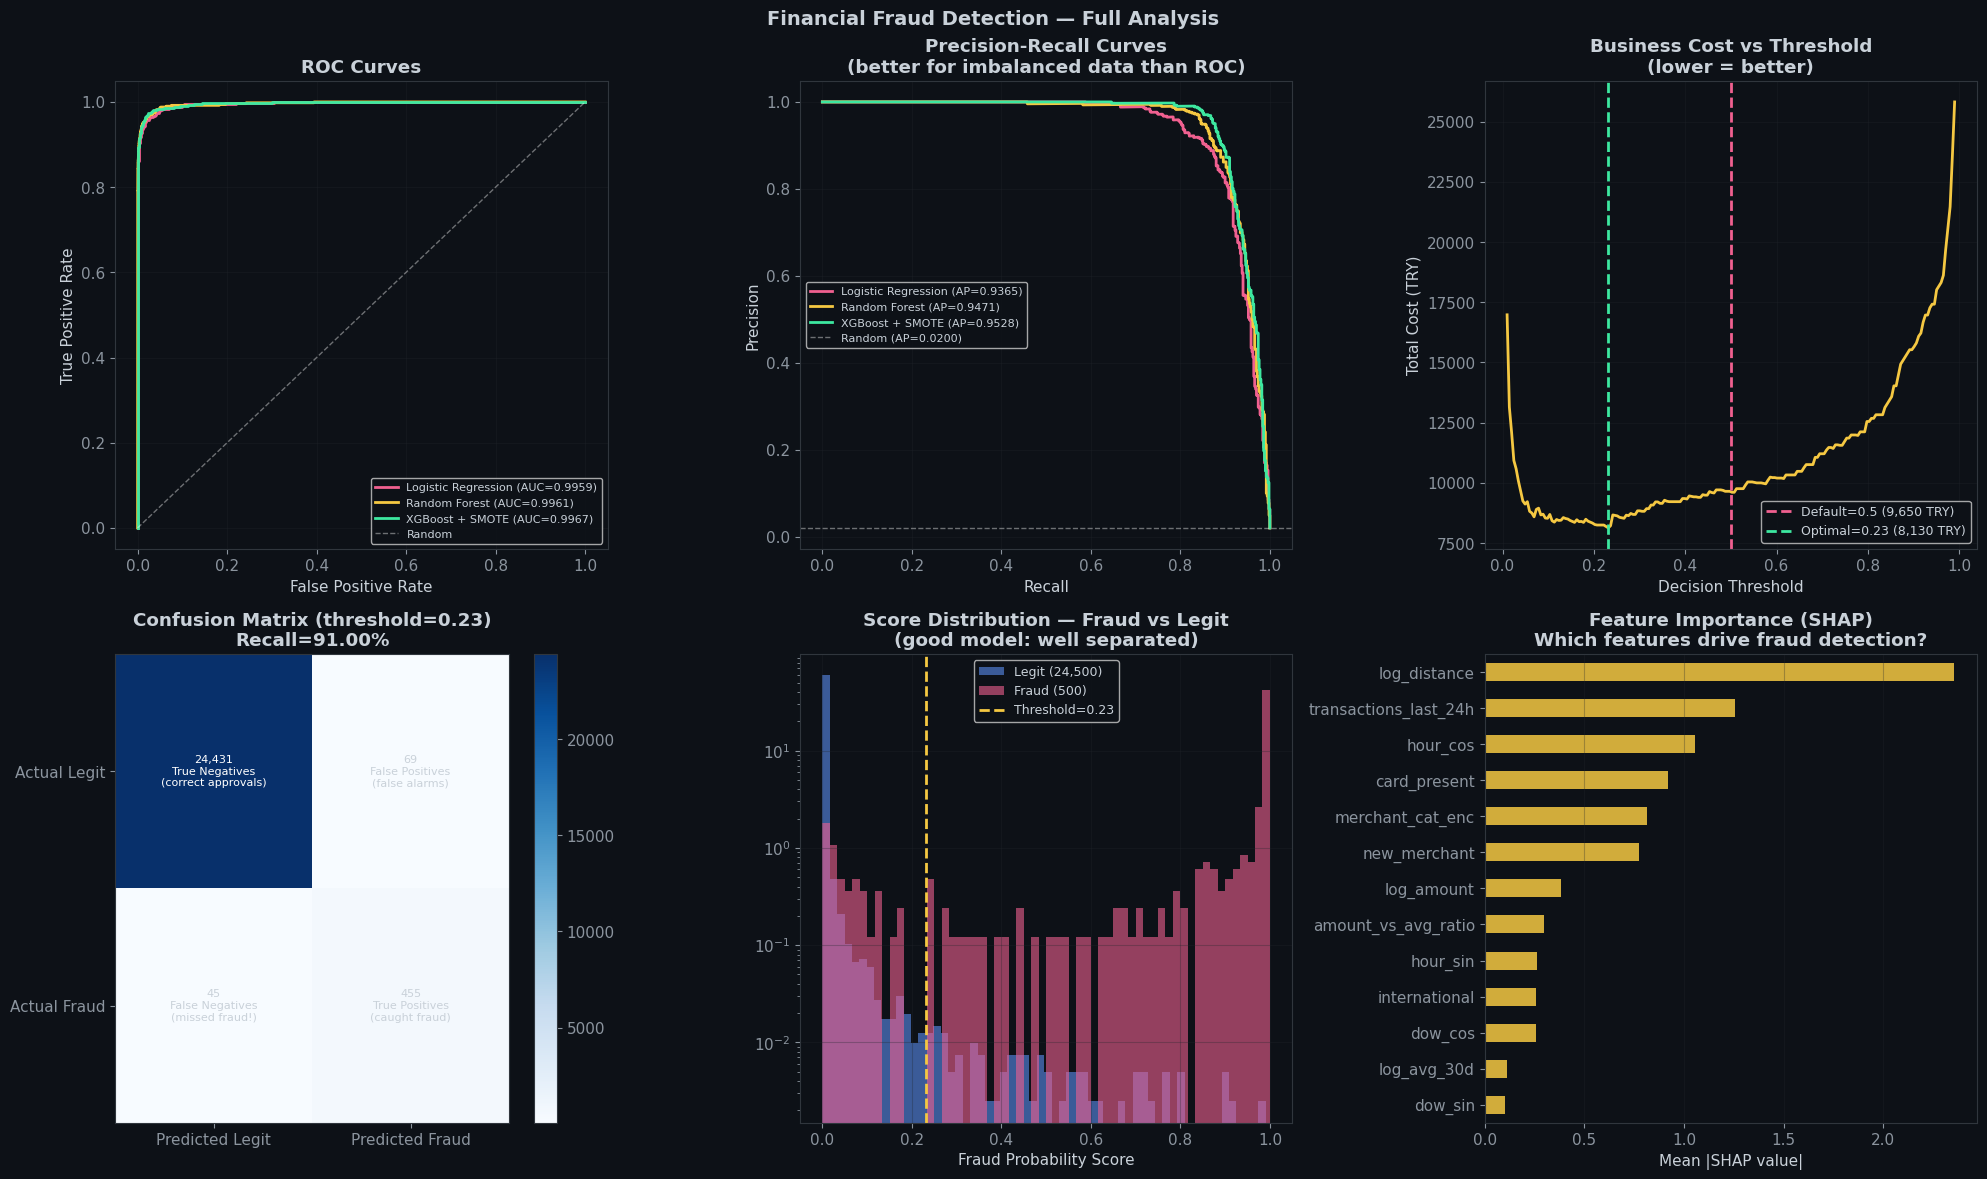


Top 3 fraud signals (SHAP):
  hour_cos: 1.0570
  transactions_last_24h: 1.2575
  log_distance: 2.3520


In [8]:
COST_MISSED_FRAUD = 150   # TRY — average loss per undetected fraud
COST_FALSE_ALARM  = 20    # TRY — cost per false positive (customer service + churn risk)

# Use XGBoost (best model) for threshold analysis
best_proba = xgb_proba

thresholds = np.linspace(0.01, 0.99, 200)
total_costs, precisions, recalls, f1s = [], [], [], []

for t in thresholds:
    preds = (best_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    cost = fn * COST_MISSED_FRAUD + fp * COST_FALSE_ALARM
    total_costs.append(cost)
    precisions.append(precision_score(y_test, preds, zero_division=0))
    recalls.append(recall_score(y_test, preds, zero_division=0))
    f1s.append(f1_score(y_test, preds, zero_division=0))

opt_idx   = np.argmin(total_costs)
opt_thresh = thresholds[opt_idx]
opt_cost   = total_costs[opt_idx]

opt_preds = (best_proba >= opt_thresh).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, opt_preds).ravel()

print(f'COST-OPTIMISED THRESHOLD: {opt_thresh:.3f}')
print(f'(vs default 0.5)')
print()

for label, thresh in [('Default (0.5)', 0.5), (f'Optimised ({opt_thresh:.3f})', opt_thresh)]:
    p = (best_proba >= thresh).astype(int)
    tn2, fp2, fn2, tp2 = confusion_matrix(y_test, p).ravel()
    cost2 = fn2 * COST_MISSED_FRAUD + fp2 * COST_FALSE_ALARM
    print(f'{label}:')
    print(f'  True Positives (caught fraud):   {tp2:,}')
    print(f'  False Negatives (missed fraud):  {fn2:,}')
    print(f'  False Positives (false alarms):  {fp2:,}')
    print(f'  Recall:     {recall_score(y_test,p):.3%}')
    print(f'  Precision:  {precision_score(y_test,p,zero_division=0):.3%}')
    print(f'  Total cost: {cost2:,} TRY / test period')
    print()

cost_at_default = total_costs[np.argmin(np.abs(thresholds - 0.5))]
savings = cost_at_default - opt_cost
print(f'Cost savings from threshold optimisation: {savings:,} TRY')

# Full results visualisation
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Financial Fraud Detection — Full Analysis', fontsize=14, fontweight='bold')

# 1. ROC curves
for name, proba, color in zip(models.keys(), models.values(), ['#f06090','#f5c842','#3de8a0']):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0,0].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.4f})')
axes[0,0].plot([0,1],[0,1],'w--',lw=1,alpha=0.4,label='Random')
axes[0,0].set_xlabel('False Positive Rate'); axes[0,0].set_ylabel('True Positive Rate')
axes[0,0].set_title('ROC Curves', fontweight='bold')
axes[0,0].legend(fontsize=8); axes[0,0].grid(True, alpha=0.3)

# 2. Precision-Recall curves (more informative for imbalanced data)
for name, proba, color in zip(models.keys(), models.values(), ['#f06090','#f5c842','#3de8a0']):
    prec_c, rec_c, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[0,1].plot(rec_c, prec_c, color=color, lw=2, label=f'{name} (AP={ap:.4f})')
axes[0,1].axhline(y_test.mean(), color='white', ls='--', lw=1, alpha=0.4, label=f'Random (AP={y_test.mean():.4f})')
axes[0,1].set_xlabel('Recall'); axes[0,1].set_ylabel('Precision')
axes[0,1].set_title('Precision-Recall Curves\n(better for imbalanced data than ROC)', fontweight='bold')
axes[0,1].legend(fontsize=8); axes[0,1].grid(True, alpha=0.3)

# 3. Total cost vs threshold
axes[0,2].plot(thresholds, total_costs, color='#f5c842', lw=2)
axes[0,2].axvline(0.5, color='#f06090', lw=2, ls='--', label=f'Default=0.5 ({cost_at_default:,} TRY)')
axes[0,2].axvline(opt_thresh, color='#3de8a0', lw=2, ls='--', label=f'Optimal={opt_thresh:.2f} ({opt_cost:,} TRY)')
axes[0,2].set_xlabel('Decision Threshold'); axes[0,2].set_ylabel('Total Cost (TRY)')
axes[0,2].set_title('Business Cost vs Threshold\n(lower = better)', fontweight='bold')
axes[0,2].legend(fontsize=9); axes[0,2].grid(True, alpha=0.3)

# 4. Confusion matrix — optimised threshold
cm = confusion_matrix(y_test, opt_preds)
labels_cm = [['True Negatives\n(correct approvals)', 'False Positives\n(false alarms)'],
              ['False Negatives\n(missed fraud!)', 'True Positives\n(caught fraud)']]
im = axes[1,0].imshow(cm, cmap='Blues', aspect='auto')
axes[1,0].set_xticks([0,1]); axes[1,0].set_yticks([0,1])
axes[1,0].set_xticklabels(['Predicted Legit','Predicted Fraud'])
axes[1,0].set_yticklabels(['Actual Legit','Actual Fraud'])
axes[1,0].set_title(f'Confusion Matrix (threshold={opt_thresh:.2f})\nRecall={recall_score(y_test,opt_preds):.2%}', fontweight='bold')
for i in range(2):
    for j in range(2):
        axes[1,0].text(j, i, f'{cm[i,j]:,}\n{labels_cm[i][j]}',
                        ha='center', va='center', fontsize=8,
                        color='white' if cm[i,j]>cm.max()/2 else '#c9d1d9')
plt.colorbar(im, ax=axes[1,0])

# 5. Fraud score distribution
axes[1,1].hist(best_proba[y_test==0], bins=60, alpha=0.6, color='#5b8ef0',
                label=f'Legit ({(y_test==0).sum():,})', density=True)
axes[1,1].hist(best_proba[y_test==1], bins=60, alpha=0.6, color='#f06090',
                label=f'Fraud ({(y_test==1).sum():,})', density=True)
axes[1,1].axvline(opt_thresh, color='#f5c842', lw=2, ls='--', label=f'Threshold={opt_thresh:.2f}')
axes[1,1].set_xlabel('Fraud Probability Score')
axes[1,1].set_title('Score Distribution — Fraud vs Legit\n(good model: well separated)', fontweight='bold')
axes[1,1].legend(fontsize=9); axes[1,1].grid(True, alpha=0.3)
axes[1,1].set_yscale('log')

# 6. SHAP feature importance
explainer = shap.TreeExplainer(xgb_model)
shap_vals  = explainer.shap_values(X_test_sc[:500])
shap_imp   = pd.Series(np.abs(shap_vals).mean(0), index=FEATURES).sort_values()
shap_imp.plot(kind='barh', ax=axes[1,2], color='#f5c842', alpha=0.85)
axes[1,2].set_title('Feature Importance (SHAP)\nWhich features drive fraud detection?', fontweight='bold')
axes[1,2].set_xlabel('Mean |SHAP value|'); axes[1,2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('fraud_results.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print(f'\nTop 3 fraud signals (SHAP):')
for feat, imp in shap_imp.tail(3).items():
    print(f'  {feat}: {imp:.4f}')

## Step 5 — Business Summary for the Risk Team

A data analyst's job ends with a clear recommendation, not a confusion matrix. Here is how to present fraud detection results to a non-technical risk manager.

In [10]:
final_recall    = recall_score(y_test, opt_preds)
final_precision = precision_score(y_test, opt_preds, zero_division=0)
daily_txns      = 50000  # scale to full bank
daily_fraud     = int(daily_txns * y_test.mean())
daily_caught    = int(daily_fraud * final_recall)
daily_missed    = daily_fraud - daily_caught
daily_false_alarms = int(daily_txns * (1 - y_test.mean()) * (fp / (fp + tn)))
daily_savings   = daily_caught * COST_MISSED_FRAUD - daily_false_alarms * COST_FALSE_ALARM

print('='*65)
print('EXECUTIVE SUMMARY — FOR THE RISK TEAM')
print('='*65)
print()
print('MODEL: XGBoost with SMOTE oversampling')
print(f'DECISION THRESHOLD: {opt_thresh:.2f} (cost-optimised)')
print()
print('PERFORMANCE AT SCALE (estimated for 50,000 daily transactions):')
print(f'  Fraudulent transactions per day:    ~{daily_fraud}')
print(f'  Fraud caught:                        {daily_caught} ({final_recall:.0%} recall)')
print(f'  Fraud missed:                        {daily_missed}')
print(f'  False alarms (legit flagged):        ~{daily_false_alarms}')
print()
print('FINANCIAL IMPACT:')
print(f'  Fraud prevented per day:             {daily_caught * COST_MISSED_FRAUD:,} TRY')
print(f'  False alarm cost per day:            {daily_false_alarms * COST_FALSE_ALARM:,} TRY')
print(f'  Net daily savings vs no model:       {daily_savings:,} TRY')
print(f'  Net annual savings:                  {daily_savings * 365 / 1e6:.1f}M TRY')
print()
print('HOW TO USE THE MODEL:')
print(f'  • Transactions with fraud score > {opt_thresh:.2f} → route to manual review queue')
print(f'  • Transactions with fraud score > 0.90 → auto-decline + contact customer')
print(f'  • Transactions with fraud score < {opt_thresh:.2f} → auto-approve')
print()
print('WHAT THE MODEL LOOKS AT (top 3 signals):')
top3 = shap_imp.tail(3).index.tolist()[::-1]
print(f'  1. {top3[0]} — most predictive of fraud')
print(f'  2. {top3[1]}')
print(f'  3. {top3[2]}')
print()
print('RECOMMENDED MONITORING:')
print('  • Track fraud rate weekly — if it rises, model needs retraining')
print('  • Track false alarm rate — if it rises, customer service cost increases')
print('  • Retrain model monthly with new fraud patterns')
print('  • Model drift detection: monitor AUROC weekly')

EXECUTIVE SUMMARY — FOR THE RISK TEAM

MODEL: XGBoost with SMOTE oversampling
DECISION THRESHOLD: 0.23 (cost-optimised)

PERFORMANCE AT SCALE (estimated for 50,000 daily transactions):
  Fraudulent transactions per day:    ~1000
  Fraud caught:                        910 (91% recall)
  Fraud missed:                        90
  False alarms (legit flagged):        ~138

FINANCIAL IMPACT:
  Fraud prevented per day:             136,500 TRY
  False alarm cost per day:            2,760 TRY
  Net daily savings vs no model:       133,740 TRY
  Net annual savings:                  48.8M TRY

HOW TO USE THE MODEL:
  • Transactions with fraud score > 0.23 → route to manual review queue
  • Transactions with fraud score > 0.90 → auto-decline + contact customer
  • Transactions with fraud score < 0.23 → auto-approve

WHAT THE MODEL LOOKS AT (top 3 signals):
  1. log_distance — most predictive of fraud
  2. transactions_last_24h
  3. hour_cos

RECOMMENDED MONITORING:
  • Track fraud rate weekly — i